In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans


In [23]:
df=pd.read_csv('Wholesale customers data.csv')

In [24]:
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


<Axes: >

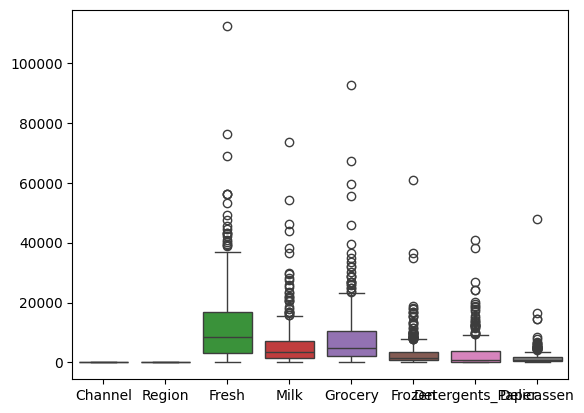

In [25]:
sns.boxplot(df)


In [26]:
main_pipe=Pipeline(steps=[('scaling',RobustScaler()),
                         ('model',KMeans(n_clusters=2,random_state=42))])

In [27]:
main_pipe.fit(df)

,steps,"[('scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,n_clusters,2
,init,'k-means++'


In [28]:
main_pipe.fit_transform(df)    #fit_transform returns the distance

array([[ 8.11999183,  1.52924557],
       [ 7.62103997,  1.43930122],
       [ 6.28235669,  4.84098534],
       [ 8.62765128,  1.6838609 ],
       [ 6.94884499,  3.06348865],
       [ 8.36586804,  1.3316294 ],
       [ 8.92998226,  1.32423001],
       [ 7.74919553,  1.42016343],
       [ 9.07345129,  1.1737195 ],
       [ 6.67731305,  2.60990982],
       [ 7.39273209,  1.74289282],
       [ 9.42059465,  1.3944208 ],
       [ 6.93533778,  2.72399274],
       [ 7.67394369,  1.95834985],
       [ 7.28272029,  2.1210043 ],
       [ 9.58852298,  1.43607731],
       [ 8.03734988,  1.86201916],
       [ 7.93035881,  2.60927479],
       [ 7.30268172,  1.77989448],
       [ 9.01379849,  1.22236124],
       [ 8.30088784,  1.3215131 ],
       [ 9.46807738,  1.34741859],
       [ 7.45663603,  3.60670197],
       [ 7.10498663, 12.43875942],
       [ 5.74514058,  3.68091458],
       [ 8.95360733,  1.61173104],
       [ 9.31111565,  1.18098105],
       [ 9.67446333,  1.52831977],
       [ 4.45606336,

In [29]:
main_pipe.fit_predict(df)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

### Elbow method

In [33]:
metrics=[]
for cluster in range(1,10):
    main_pipe=Pipeline(
        steps=[('scaling',RobustScaler()),
                ('model',KMeans(n_clusters=cluster,random_state=42))
                ]
    )
    main_pipe.fit(df)
    metric=main_pipe.named_steps['model'].inertia_
    metrics.append(metric)

print(metrics)    

[5825.748476797495, 4552.477998715872, 3997.0600566986004, 3415.541631619126, 2563.6476342065307, 2429.918228854141, 1930.6146246504688, 1599.8641157554719, 1451.8324508608496]


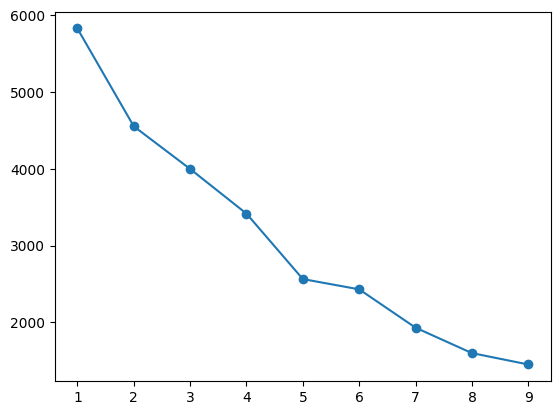

In [34]:
plt.plot(range(1,10),metrics,marker='o')
plt.show()

The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm. The inertia decreased significantly up to K = 5, after which the rate of decrease became gradual. Hence, the optimal number of clusters was selected as 5, as it provides a good balance between minimizing within-cluster variance and avoiding unnecessary complexity.